In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
reload(helpers)
n_parts = 2

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5", n_parts, label="Fryer+2012 Delayed", colour="C0"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/binaries-remnantflag-3", n_parts, label="Fryer+2012 Rapid", colour="C1"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/binaries-remnantflag-2", n_parts, label="StarTrack", colour="C2"),
]

Loading distributed population Fryer+2012 Delayed from 2 parts
   loaded part 1/2 of Fryer+2012 Delayed with 179379 binaries
   loaded part 2/2 of Fryer+2012 Delayed with 178696 binaries
Loading distributed population Fryer+2012 Rapid from 2 parts


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/ceph/users/twagg/underworld/binaries-remnantflag-3_part0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [14]:
kinematics = helpers.get_kinematics(pops)

Inner 10 kpc
  Fryer+2012 Delayed fraction within 0.5 kpc 0.47
  Fryer+2012 Rapid fraction within 0.5 kpc 0.49
  StarTrack fraction within 0.5 kpc 0.50
Full population
  Fryer+2012 Delayed fraction within 0.5 kpc 0.37
  Fryer+2012 Rapid fraction within 0.5 kpc 0.38
  StarTrack fraction within 0.5 kpc 0.39


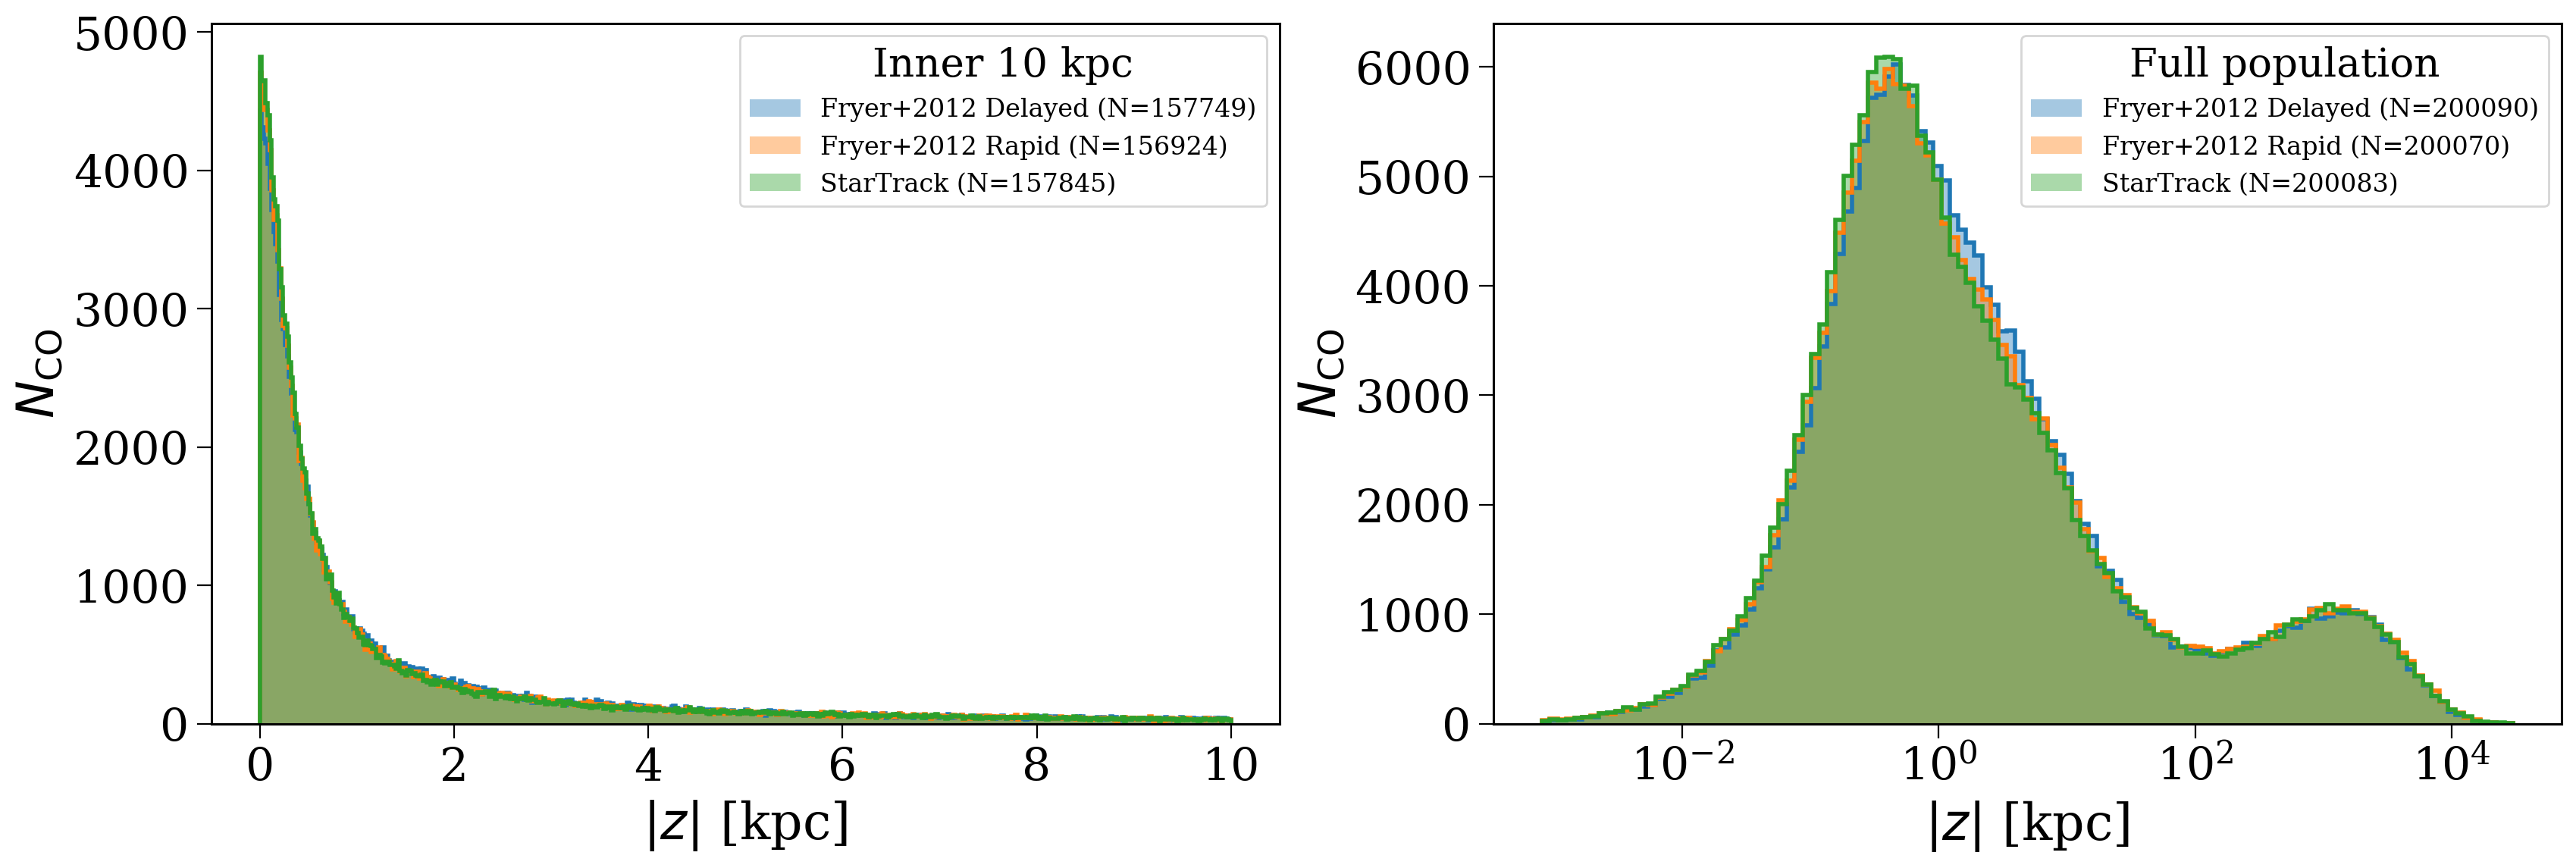

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [15]:
plotting.absolute_galactocentric_height(pops, kinematics)

In [16]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Fryer+2012 Delayed:
      - CO = 0.112
      - BH = 0.030
      - NS = 0.143
  - Fryer+2012 Rapid:
      - CO = 0.115
      - BH = 0.008
      - NS = 0.145
  - StarTrack:
      - CO = 0.113
      - BH = 0.013
      - NS = 0.144


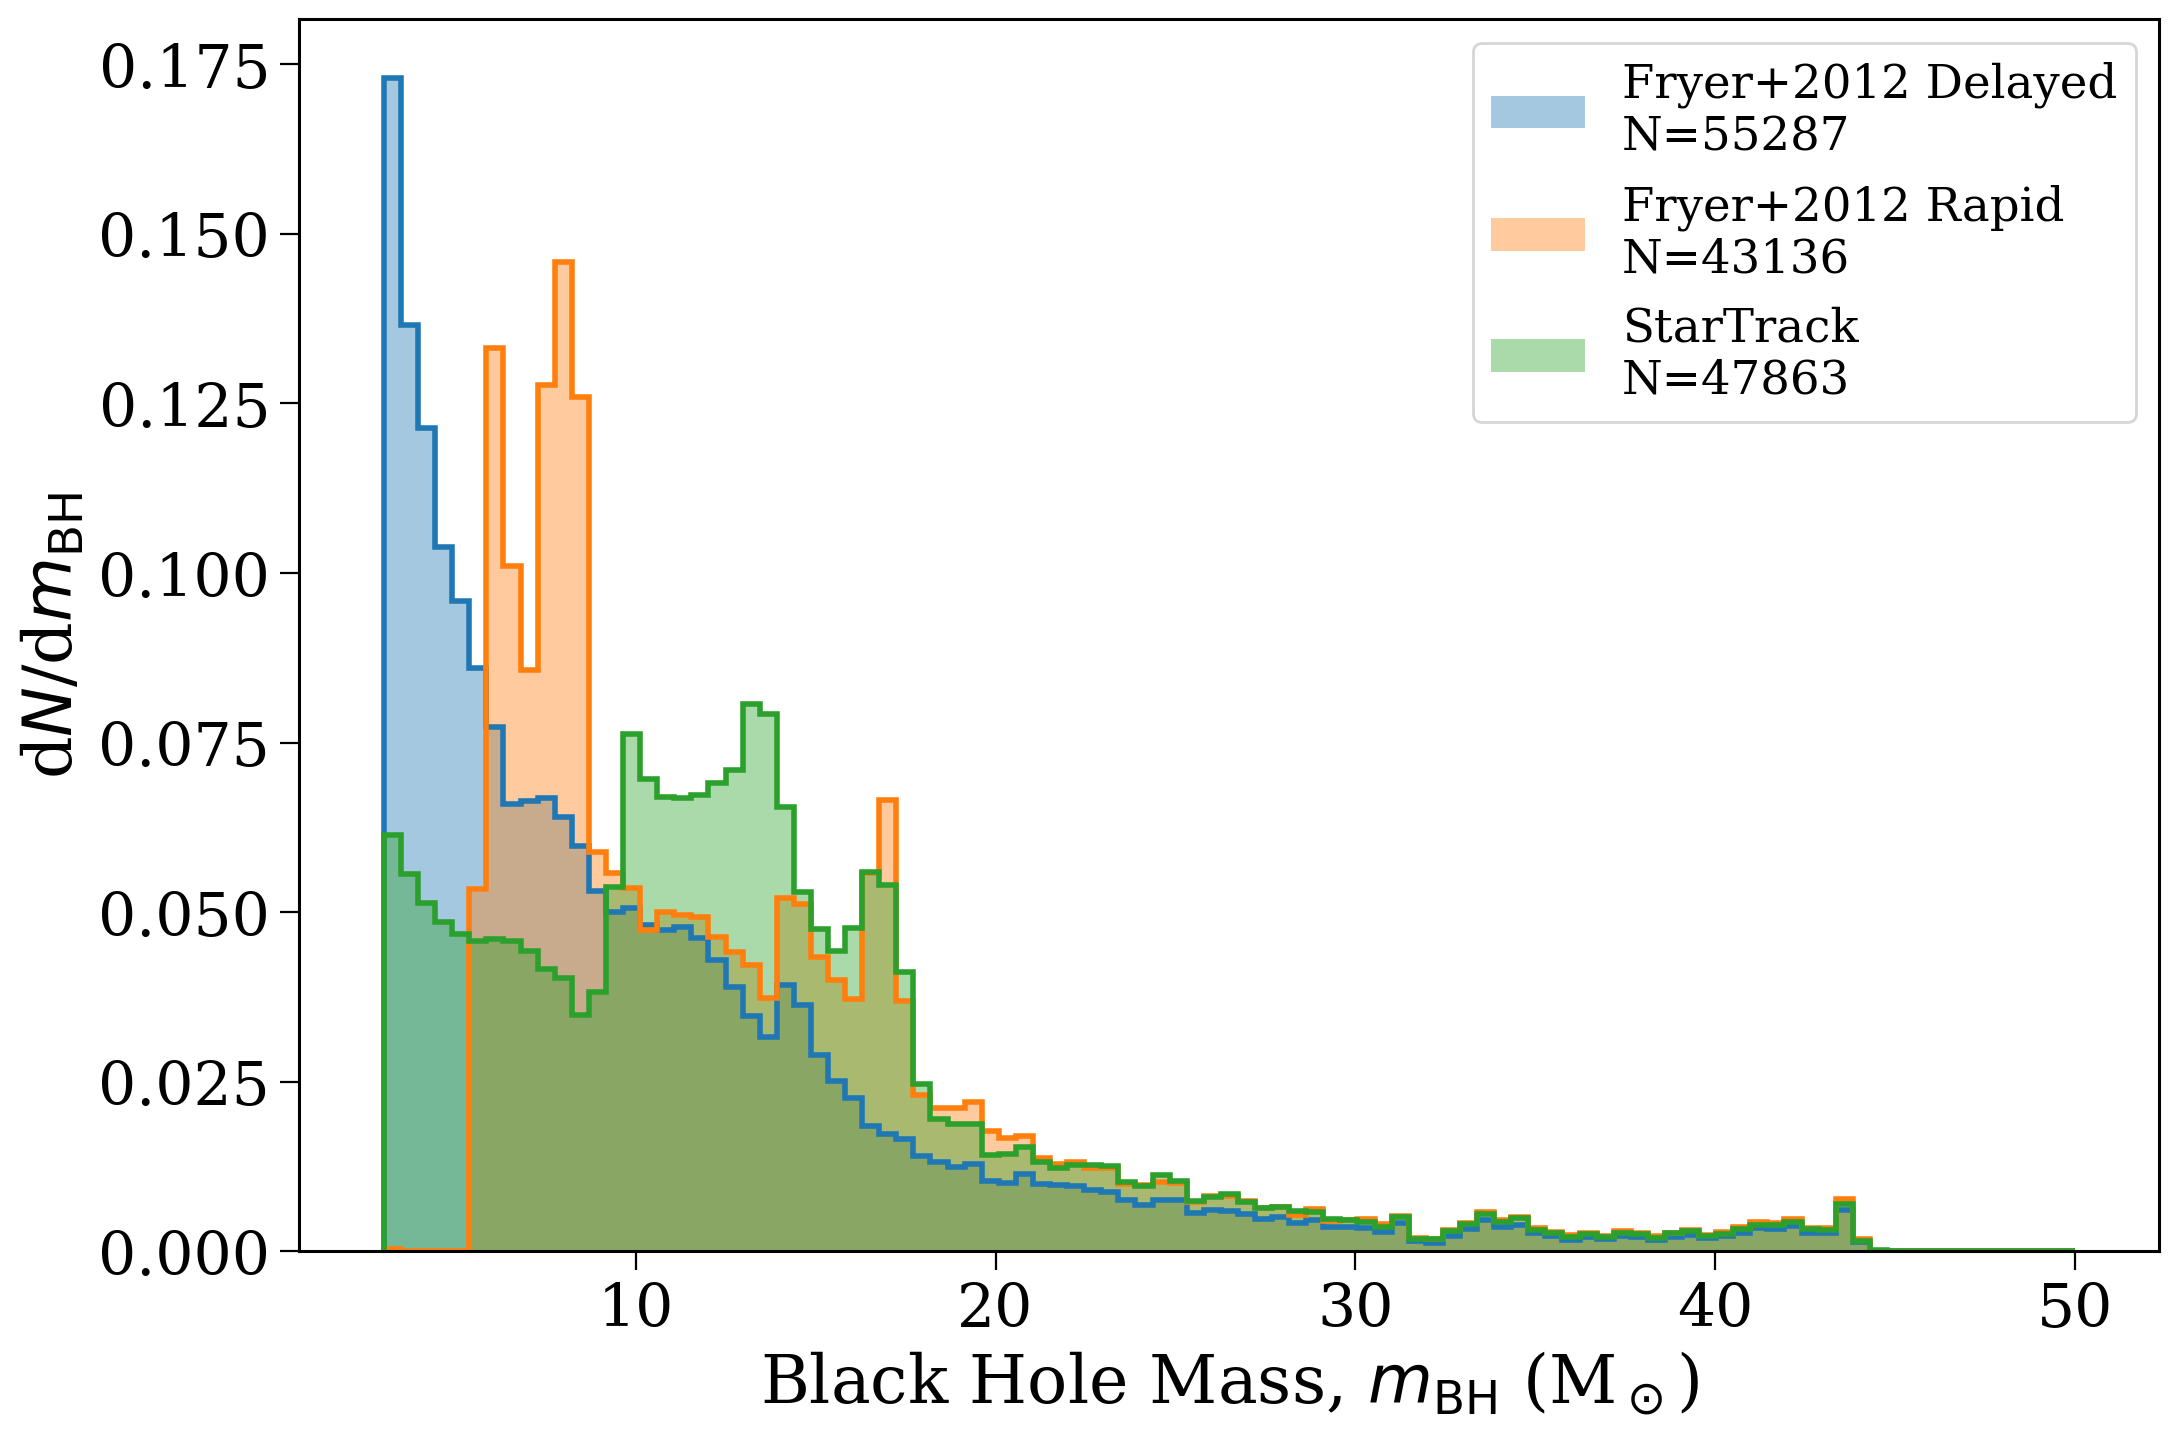

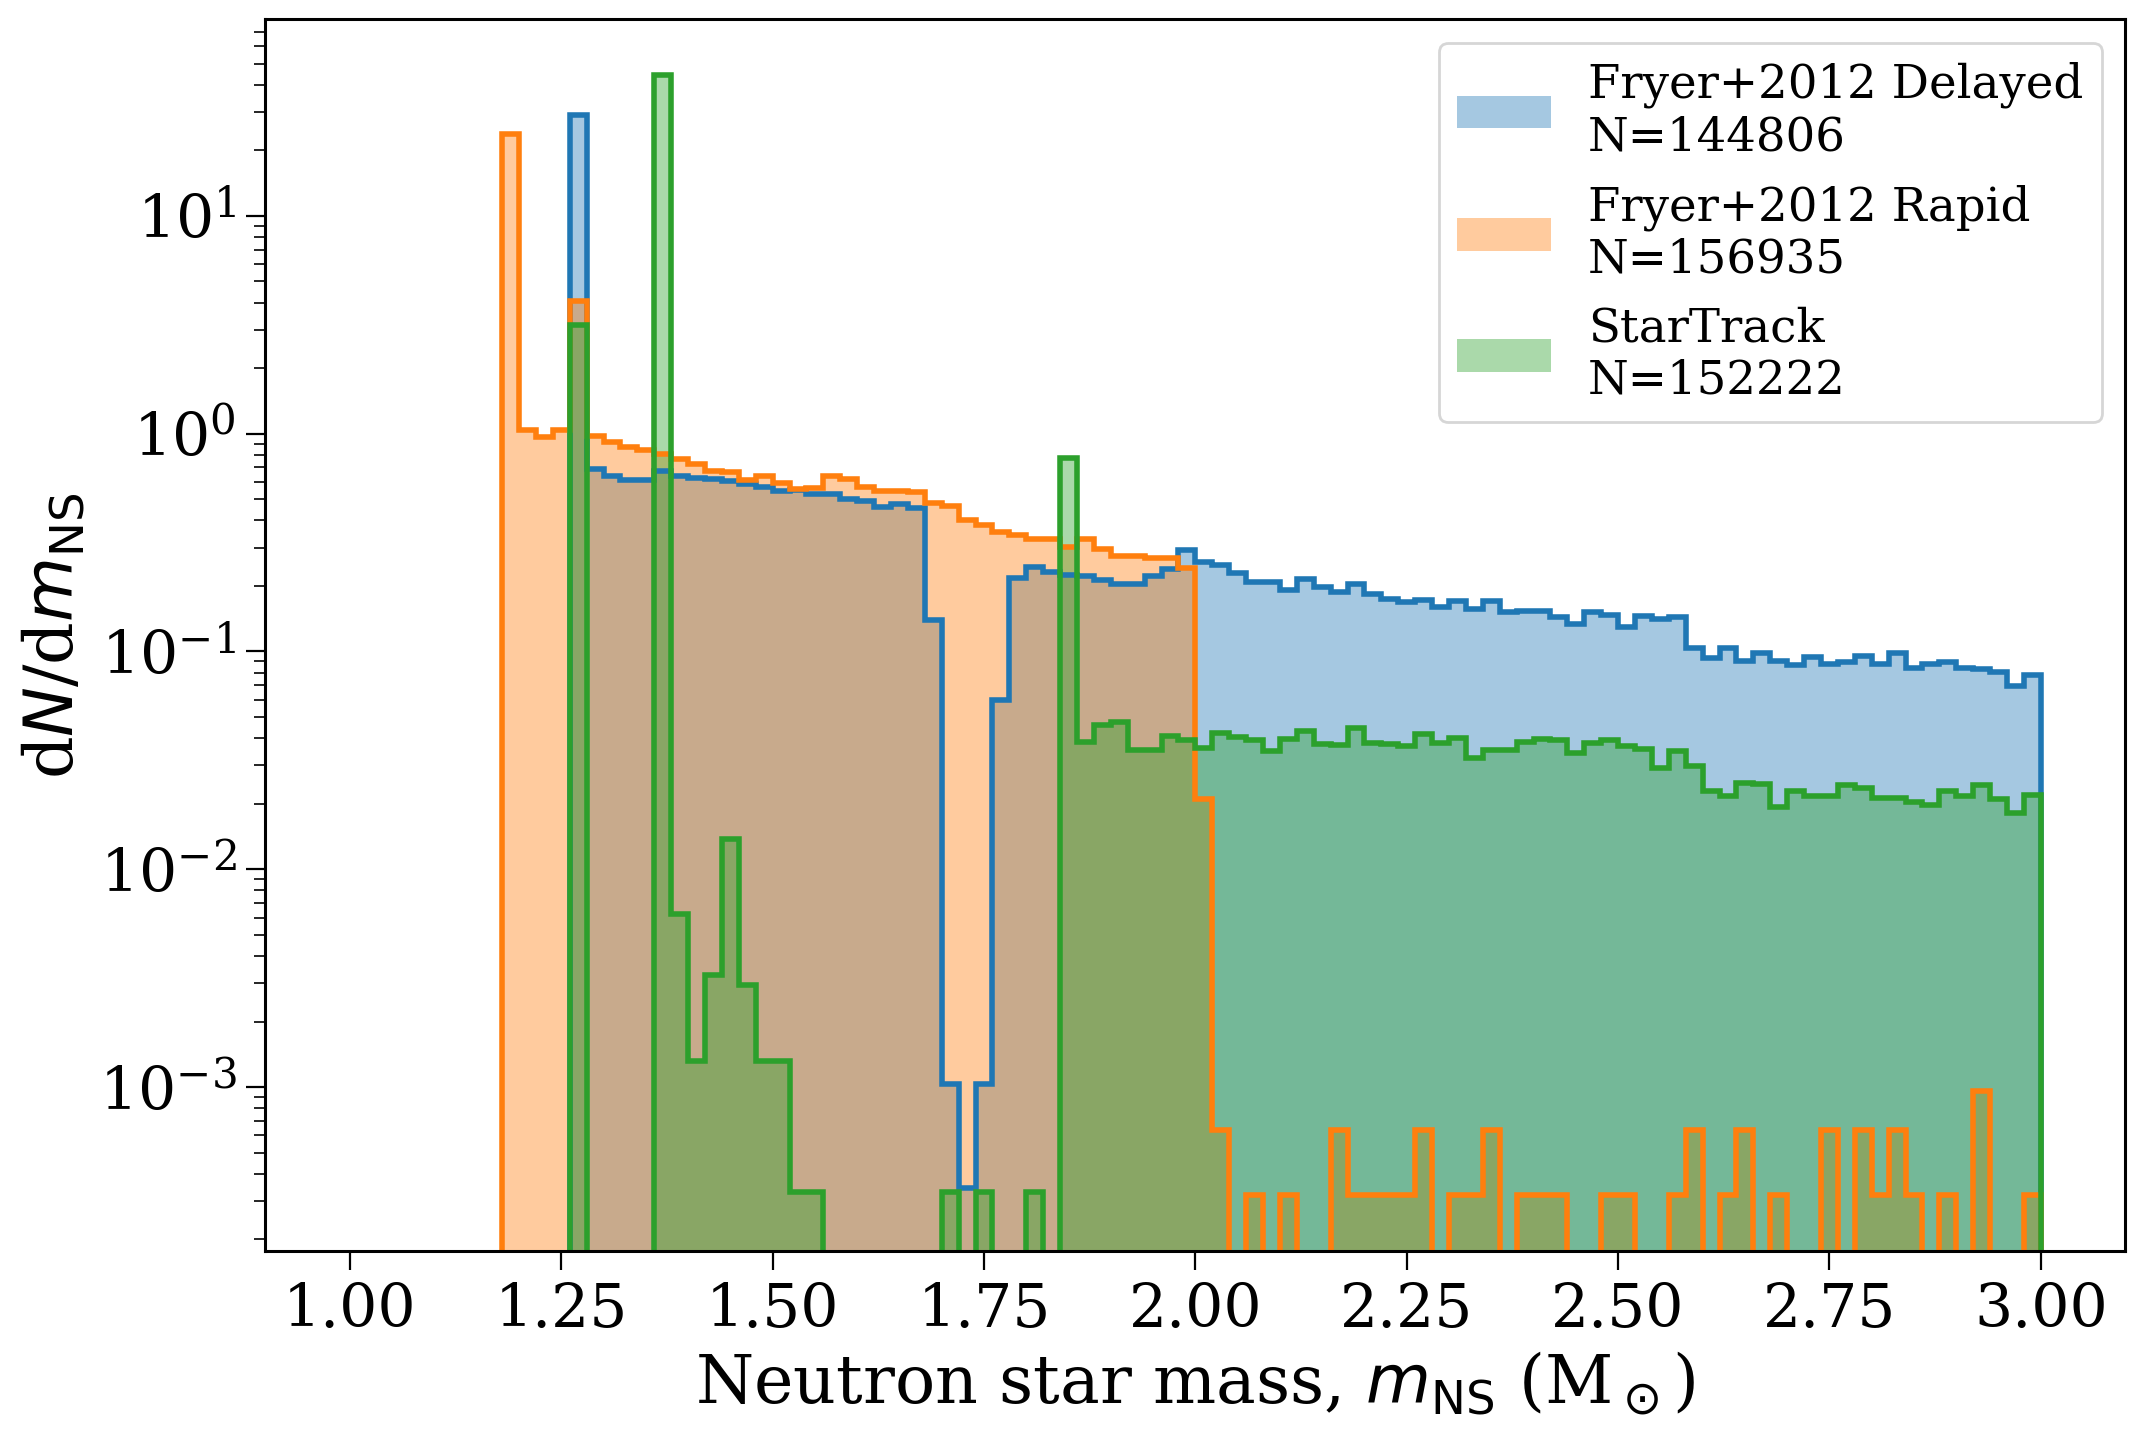

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Neutron star mass, $m_{\\rm NS}$ (M$_\\odot$)', ylabel='d$N$/d$m_{\\rm NS}$'>)

In [17]:
fig, ax = plotting.compare_table_quantity(
    pops=pops,
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)
plt.show()
plotting.compare_table_quantity(
    pops=pops,
    quantity="mass",
    kstar=13,
    bins=np.linspace(1, 3, 101),
    xlabel=r"Neutron star mass, $m_{\rm NS}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm NS}$",
    yscale='log'
)